In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Import Libraries

## Objective

Import all required libraries for model evaluation and analysis.

## Methodology

The notebook uses:

- Pandas and NumPy
- Joblib
- Matplotlib
- Scikit-learn evaluation metrics

## Expected Output

Libraries successfully imported.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    auc
)

In [3]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

PROJECT_NAME = "Personal Knowledge Decay Predictor"

matches = [
    p for p in Path("/content/drive/MyDrive").rglob(PROJECT_NAME)
    if p.is_dir()
]

PROJECT_ROOT = matches[0]

sys.path.append(str(PROJECT_ROOT))

from config import *

print("✅ Project Root :", PROJECT_ROOT)

✅ Project Root : /content/drive/MyDrive/Marwadi_uiniversity/Personal Knowledge Decay Predictor
✅ Project Root : /content/drive/MyDrive/Marwadi_uiniversity/Personal Knowledge Decay Predictor


# 2. Load Saved Model

## Objective

Load the best-performing machine learning model saved in Notebook 05.

## Expected Output

The trained prediction model.

In [4]:
import joblib

best_model = joblib.load(
    f"{MODEL_DIR}/best_model.pkl"
)

print("Model Type:", type(best_model))

Model Type: <class 'sklearn.linear_model._logistic.LogisticRegression'>


# 3. Load Dataset

## Objective

Load the processed dataset used for model evaluation.

## Expected Output

The target-engineered dataset.

In [5]:
df = pd.read_csv(
    f"{DATA_DIR}/Processed/model_ready_dataset.csv",
    low_memory=False
)

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (871614, 85)


,studentId,SY ASSISTments Usage,AveKnow,AveCarelessness,AveCorrect,NumActions,AveResBored,AveResEngcon,AveResConf,AveResFrust,...,Ln,MCAS,interaction_order,past_attempts,past_correct,past_accuracy,rolling_accuracy,mastered,future_accuracy,forget_event
0,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.759192485,45,1,0,0.0,0.0,NaN,0,0.789474,0
1,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.908767782,45,2,1,1.0,1.0,NaN,0,0.777778,0
2,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.969112157,45,3,2,2.0,1.0,NaN,0,0.764706,0
3,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.989972799,45,4,3,3.0,1.0,NaN,0,0.750000,0
4,8,2004-2005,0.352417,0.183276,0.483901,1056,0.208389,0.679126,0.115905,0.112408,...,0.936555224,45,5,4,4.0,1.0,NaN,0,0.800000,0


📒 Section 4 — Recreate Train/Test Split

We recreate the same split used in Notebook 05.

In [6]:
feature_columns = [
    "interaction_order",
    "past_attempts",
    "past_correct",
    "past_accuracy",
    "rolling_accuracy",
    "mastered"
]

X = df[feature_columns]

y = df["forget_event"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [7]:
scaler = joblib.load(
    f"{MODEL_DIR}/scaler.pkl"
)
print("Model Type:", type(best_model))
X_test_scaled = scaler.transform(X_test)

Model Type: <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [8]:
print("Missing values in X_test:")

print(X_test.isnull().sum())

Missing values in X_test:
interaction_order        0
past_attempts            0
past_correct             0
past_accuracy            0
rolling_accuracy     49115
mastered                 0
dtype: int64


In [9]:
print("\nTotal Missing Values:")

print(X_test.isnull().sum().sum())


Total Missing Values:
49115


In [10]:
df = df.dropna(subset=["rolling_accuracy"]).reset_index(drop=True)

print(df["rolling_accuracy"].isnull().sum())

0


In [11]:
df = df.dropna(subset=["rolling_accuracy"]).reset_index(drop=True)

In [12]:
# =====================================================
# Recreate Feature Matrix
# =====================================================

feature_columns = [
    "interaction_order",
    "past_attempts",
    "past_correct",
    "past_accuracy",
    "rolling_accuracy",
    "mastered"
]

X = df[feature_columns]
y = df["forget_event"]

In [13]:
# =====================================================
# Train/Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
X_test_scaled = scaler.transform(X_test)

# 5. Generate Predictions

## Objective

Generate predictions using the saved Logistic Regression model.

## Methodology

The trained model predicts both the class labels and class probabilities for the testing dataset.

## Expected Output

Predicted labels and probabilities.

In [15]:
# =====================================================
# Generate Predictions
# =====================================================

y_pred = best_model.predict(X_test_scaled)

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("Prediction completed successfully.")

Prediction completed successfully.


# 6. ROC Curve

## Objective

Evaluate the model's ability to distinguish between forgetting and non-forgetting events.

## Methodology

The Receiver Operating Characteristic (ROC) curve is plotted and the Area Under the Curve (ROC-AUC) is calculated.

## Expected Output

ROC curve and AUC score.

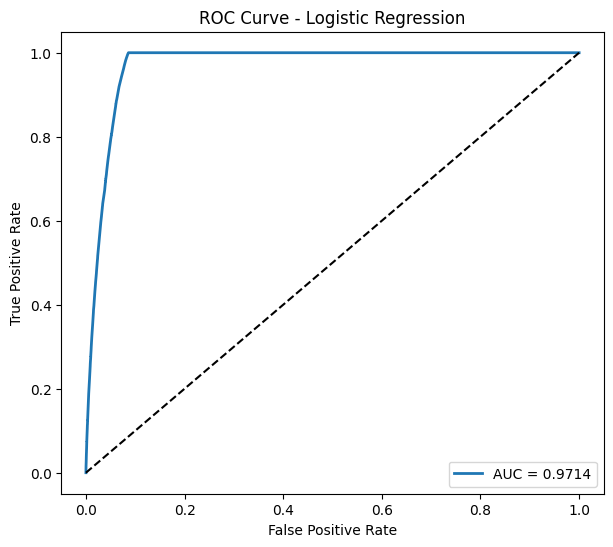

In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

# 7. Precision–Recall Curve

## Objective

Evaluate the trade-off between precision and recall.

## Expected Output

Precision–Recall curve.

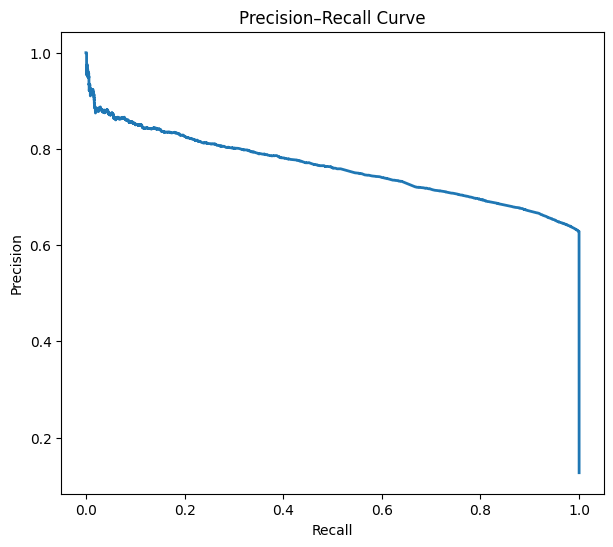

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.show()

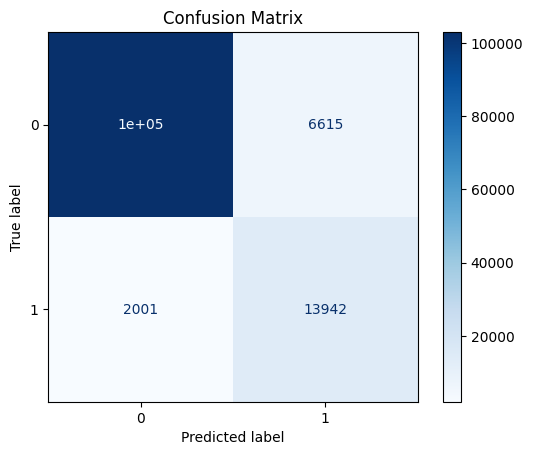

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

In [19]:
coef_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": best_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

display(coef_df)

,Feature,Coefficient
5,mastered,4.669651
0,interaction_order,0.411319
1,past_attempts,0.411319
4,rolling_accuracy,-0.217865
3,past_accuracy,-0.378388
2,past_correct,-0.566028


# 9. Error Analysis

## Objective

Analyze incorrect predictions made by the model.

## Methodology

False Positives and False Negatives are identified to better understand the model's weaknesses.

## Expected Output

Counts of prediction errors.

In [20]:
# =====================================================
# Error Analysis
# =====================================================

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

error_df = pd.DataFrame({
    "Category": [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    "Count": [
        tp,
        tn,
        fp,
        fn
    ]
})

display(error_df)

,Category,Count
0,True Positive,13942
1,True Negative,102983
2,False Positive,6615
3,False Negative,2001


# 10. Business Interpretation

## Objective

Interpret the model results in the context of adaptive learning.

## Discussion

The trained Logistic Regression model achieved strong predictive performance.

The high recall indicates that the model successfully identifies most students who are likely to experience knowledge decay.

Such predictions can be used to trigger personalized revision activities before significant forgetting occurs.

The model therefore supports proactive interventions within adaptive educational systems.

# 11. Limitations

Although the model achieved strong predictive performance, several limitations remain.

- The study uses a single educational dataset.
- Only historical interaction features were considered.
- Knowledge decay was approximated using rolling accuracy and future accuracy.
- The evaluation used a stratified train-test split rather than a strictly chronological split.
- Future work may incorporate richer learner profiles, temporal models, and multi-subject educational data.

# Notebook Summary

This notebook evaluated the selected Logistic Regression model.

The following tasks were completed:

- Loaded the saved prediction model
- Recreated the evaluation dataset
- Generated predictions
- Evaluated model performance using ROC and Precision–Recall curves
- Analyzed the confusion matrix
- Interpreted model coefficients
- Performed error analysis
- Discussed practical implications and limitations

The trained model demonstrated strong capability for predicting future forgetting events and is suitable for integration into an adaptive learning framework.